In [40]:
import random
from collections import namedtuple

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, optimizers

Transition = namedtuple("Transition", ("state", "action", "next_state", "reward", "done"))

class ReplayMemory:
    def __init__(self, capacity=20000):
        self.capacity = capacity
        self.memory = []
        self.position = 0

    def push(self, *args):
        if len(self.memory) < self.capacity:
            self.memory.append(None)
        self.memory[self.position] = Transition(*args)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.memory, batch_size)
        states, actions, next_states, rewards, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int32),
            np.array(next_states, dtype=np.float32),
            np.array(rewards, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )

    def __len__(self):
        return len(self.memory)


In [41]:
class DQNAgent:
    def __init__(self, env, gamma=0.99, epsilon=1.0, epsilon_min=0.05,
                 epsilon_decay=0.999, lr=1e-3, batch_size=64):

        self.env = env
        self.n_actions = int(env.action_space.n)   # IMPORTANT FIX
        self.state_dim = 3                         # Blackjack state = (player, dealer, usable_ace)

        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.lr = lr
        self.batch_size = batch_size

        self.memory = ReplayMemory()
        self.model = self._build_model()
        self.losses = []

    def _build_model(self):
        model = tf.keras.Sequential([
            layers.Input(shape=(self.state_dim,)),
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(self.n_actions, name="q_values")
        ])
        model.compile(
            optimizer=optimizers.Adam(learning_rate=self.lr),
            loss="mse"
        )
        model.summary()
        return model

    def select_action(self, state):
        if np.random.rand() < self.epsilon:
            return self.env.action_space.sample()

        state = np.array(state, dtype=np.float32).reshape(1, -1)
        q_values = self.model.predict(state, verbose=0)[0]
        return int(np.argmax(q_values))

    def play_step(self):
        state, info = self.env.reset()
        done = False
        total_reward = 0.0

        while not done:
            action = self.select_action(state)
            next_state, reward, terminated, truncated, info = self.env.step(action)
            done = terminated or truncated

            self.memory.push(
                np.array(state, dtype=np.float32),
                action,
                np.array(next_state, dtype=np.float32),
                reward,
                done
            )

            state = next_state
            total_reward += reward

        # epsilon decay
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        return total_reward

    def learn(self):
        if len(self.memory) < self.batch_size:
            return

        states, actions, next_states, rewards, dones = self.memory.sample(self.batch_size)

        q_values = self.model.predict(states, verbose=0)
        next_q_values = self.model.predict(next_states, verbose=0)
        max_next_q = np.max(next_q_values, axis=1)

        targets = q_values.copy()
        for i in range(self.batch_size):
            targets[i, actions[i]] = rewards[i] + (1 - dones[i]) * self.gamma * max_next_q[i]

        history = self.model.fit(states, targets, epochs=1, verbose=0)
        self.losses.append(history.history["loss"][-1])


In [42]:
import gymnasium as gym

env = gym.make("Blackjack-v1")
agent = DQNAgent(env=env, epsilon=1.0, lr=1e-3, batch_size=64)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 64)                  │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ q_values (Dense)                     │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,546 (17.76 KB)

 Trainable params: 4,546 (17.76 KB)

 Non-trainable params: 0 (0.00 B)

In [44]:
from tqdm.notebook import trange

num_episodes = 500
rewards = []
best_100 = -1.0

for episode in trange(num_episodes):
    total_reward = agent.play_step()
    agent.learn()
    rewards.append(total_reward)

    if len(rewards) >= 100:
        mean_100 = np.mean(rewards[-100:])
        if mean_100 > best_100:
            best_100 = mean_100

        if episode % 100 == 0:
            print(f"Episode {episode}, avg last 100: {mean_100:.3f}, epsilon: {agent.epsilon:.3f}")

print(f"Best 100-episode average reward: {best_100:.3f}")


  0%|          | 0/500 [00:00<?, ?it/s]

Episode 100, avg last 100: -0.260, epsilon: 0.830
Episode 200, avg last 100: -0.310, epsilon: 0.751
Episode 300, avg last 100: -0.350, epsilon: 0.680
Episode 400, avg last 100: -0.220, epsilon: 0.615
Best 100-episode average reward: -0.160


In [45]:
agent.memory.capacity = 20000

In [46]:
agent.batch_size = 1000

In [52]:
from tqdm.notebook import trange

num_rounds = 500
exploit_runs = num_rounds // 5
best_100 = -1.0

payouts = []
epsilons = np.hstack([
    np.linspace(0.5, 0.01, num=num_rounds - exploit_runs), 
    np.zeros(exploit_runs)
])
for sample in trange(num_rounds):
    epsilon = epsilons[sample]
    agent.epsilon = epsilon
    total_payout = 0
    #state = agent.env.reset()
    state, info = agent.env.reset()

    for _ in range(10):
        #state, payout, done = agent.play(state)
        payout = agent.play_step()
        total_payout += payout
        if done:
            break
    if epsilon > 0:
        agent.learn()
    
    mean_100 = np.mean(payouts[-100:])
    if mean_100 > best_100:
        best_100 = mean_100

    payouts.append(total_payout)
    if (sample % 100) == 0 and sample >= 100:
        
        print('average payout: {:.3f}'.format(
            mean_100
        ))
        print(agent.losses[-1])
        
print('best 100 average: {:.3f}'.format(best_100))

  0%|          | 0/500 [00:00<?, ?it/s]

C:\Users\yathi\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3904: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\yathi\anaconda3\Lib\site-packages\numpy\_core\_methods.py:147: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


average payout: -1.620
0.25526243448257446
average payout: -1.680
0.2708507180213928
average payout: -1.140
0.26370981335639954
average payout: -0.650
0.2497514933347702
best 100 average: 4.000


C:\Users\yathi\AppData\Local\Temp\ipykernel_42288\1850853920.py:2: DeprecationWarning: Please import `uniform_filter1d` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import uniform_filter1d
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' not found.
findfont: Font family 'normal' 

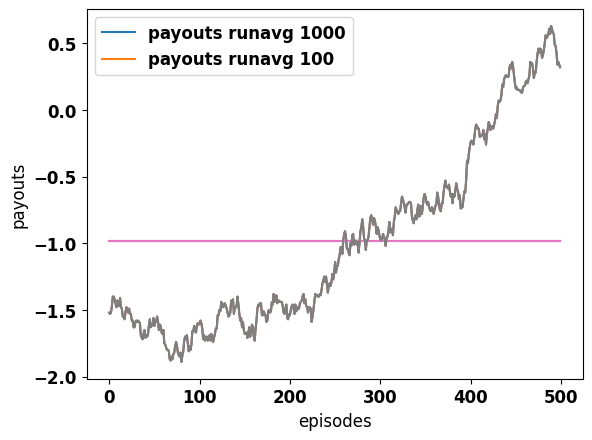

In [54]:
%matplotlib inline
from scipy.ndimage.filters import uniform_filter1d
import matplotlib
from matplotlib import pyplot as plt

font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 12}
matplotlib.rc('font', **font)

#plt.plot(payouts)           
plt.xlabel('episodes')
plt.ylabel('payouts')
plt.plot(uniform_filter1d(payouts, size=1000))
plt.plot(uniform_filter1d(payouts, size=100))
#plt.plot(uniform_filter1d(agent.losses, size=100))
plt.legend([
    'payouts runavg 1000',
    'payouts runavg 100',
    #'training losses runavg 100',
])
plt.show()